In [ ]:
#Instalar librerias
!pip install dtreeviz
!pip install catboost
!pip install shap
!pip install xgboost
!pip install optbinning
!pip install lightgbm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.8/91.8 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 213.9/213.9 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.1/28.1 MB 53.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.8/302.8 kB 15.6 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.5
    Uninstalling protobuf-5.29.5:
      Successfully uninstalled protobuf-5.29.5
  Attempting uninstall: absl-py
    Found existing installation: absl-py 1.4.0
    Uninstalling absl-py-1.4.0:
      Successfully uninstalled absl-py-1.4.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ydf 0.13.0 requires protobuf<7

In [ ]:
#Importo librerias necesarias para el proceso de EDA (Esploratory Data Analysis)
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import folium
import numpy as np
from datetime import datetime
import plotly.express as px
import plotly.graph_objects as go

#Importo librerias necesarias para el proceso de Feature engineering y evaluación de modelos
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import roc_curve, roc_auc_score, ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.model_selection import GridSearchCV

#Importo librerias necesarias para ML
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from xgboost import XGBClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import VotingClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
import shap
from sklearn.tree import export_graphviz
import graphviz
import warnings
warnings.filterwarnings("ignore")
warnings.simplefilter(action='ignore', category=FutureWarning)




In [ ]:
# Descargar los datos con pandas
df_red = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv',sep=';')

df_white = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv',sep=';')

df = pd.concat([df_red, df_white])

df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [ ]:
#No queremos incluir la variable quality dentro del tratamiento de outliers
df_outliers = df.drop(columns='quality')
df_target= df['quality']



Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

for col in df_outliers.columns:
    col_outliers = ((df_outliers[col] < (Q1[col] - 3 * IQR[col])) | (df_outliers[col] > (Q3[col] + 3 * IQR[col]))) # se detectan outliers usando el rango interquartil
    df_outliers.loc[col_outliers, col] = df_outliers[col].median() #Los reemplzamos con la mediana

df_target_b= df['quality'].apply(lambda x: 1 if x >= 7 else 0)

#Juntamos el dataset limpio con el nuevo target
df_limpio = df_outliers.copy()
df_limpio['quality'] = df_target_b
df_limpio.head()


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0


In [ ]:
# División de datos en entrenamiento y test
X = df_limpio.drop(['quality'], axis=1)
y = df_limpio['quality']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) #Usaremos division 80-20 por la cantidad de datos, lo usual en datasets más grandes es 70-30


Adaboost

In [ ]:

AB_Model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=100,
    learning_rate=0.5,
    random_state=42
)
AB_Model.fit(X_train, y_train)
y_pred = AB_Model.predict(X_test)
y_proba = AB_Model.predict_proba(X_test)


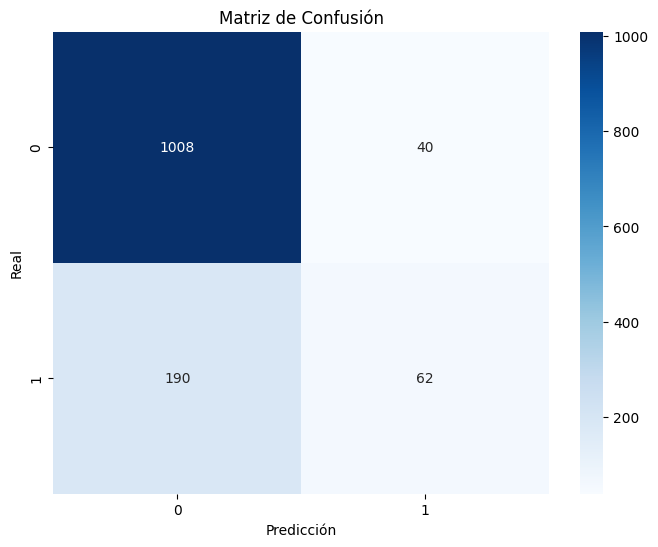

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.84      0.96      0.90      1048
           1       0.61      0.25      0.35       252

    accuracy                           0.82      1300
   macro avg       0.72      0.60      0.62      1300
weighted avg       0.80      0.82      0.79      1300



In [ ]:
#Matriz de Correlacion
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión")
plt.show()

#Reporte de Clasificación
print("Reporte de Clasificación:")
print(classification_report(y_test, y_pred))

#curva ROC
y_probs = AB_Model.predict_proba(X_test)[:, 1]  # Probabilidades para la clase positiva

fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc_score = roc_auc_score(y_test, y_probs)

fig = go.Figure()
fig.add_trace(go.Scatter(x=fpr, y=tpr, mode='lines', name='ROC', line=dict(color='royalblue')))
fig.add_trace(go.Scatter(x=[0, 1], y=[0, 1], mode='lines', name='no_model', line=dict(dash='dash')))
fig.update_layout(title=f'Curva ROC - AUC: {auc_score:.3f}',
                  xaxis_title='Tasa de Falsos Positivos (FPR)',
                  yaxis_title='Tasa de Verdaderos Positivos (TPR)',
                  width=700, height=500)
fig.show()


Gradient Boosting (GBM)

In [ ]:
GBM_Model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    subsample=0.8,
    random_state=42
)
GBM_Model.fit(X_train, y_train)
y_pred = GBM_Model.predict(X_test)
y_proba = GBM_Model.predict_proba(X_test)



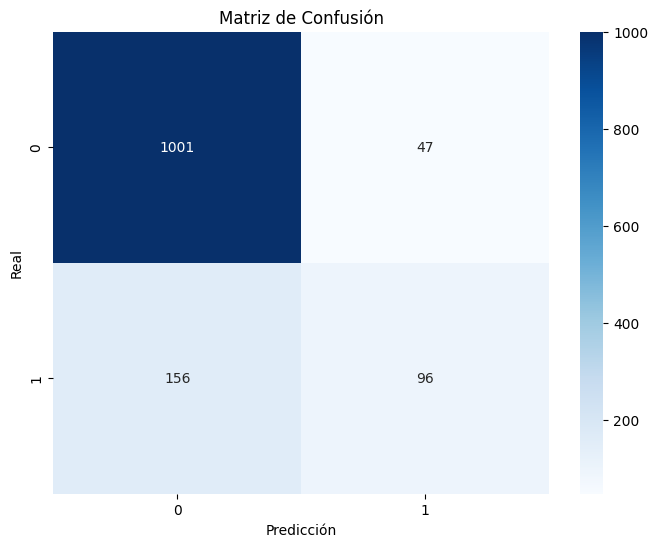

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.87      0.96      0.91      1048
           1       0.67      0.38      0.49       252

    accuracy                           0.84      1300
   macro avg       0.77      0.67      0.70      1300
weighted avg       0.83      0.84      0.83      1300



In [ ]:
#Matriz de Correlacion
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión")
plt.show()

#Reporte de Clasificación
print("Reporte de Clasificación:")
print(classification_report(y_test, y_pred))

#curva ROC
y_probs = GBM_Model.predict_proba(X_test)[:, 1]  # Probabilidades para la clase positiva

fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc_score = roc_auc_score(y_test, y_probs)

fig = go.Figure()
fig.add_trace(go.Scatter(x=fpr, y=tpr, mode='lines', name='ROC', line=dict(color='royalblue')))
fig.add_trace(go.Scatter(x=[0, 1], y=[0, 1], mode='lines', name='no_model', line=dict(dash='dash')))
fig.update_layout(title=f'Curva ROC - AUC: {auc_score:.3f}',
                  xaxis_title='Tasa de Falsos Positivos (FPR)',
                  yaxis_title='Tasa de Verdaderos Positivos (TPR)',
                  width=700, height=500)
fig.show()


XGB

In [ ]:
XGB_Model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)
XGB_Model.fit(X_train, y_train)
y_pred = XGB_Model.predict(X_test)
y_proba = XGB_Model.predict_proba(X_test)



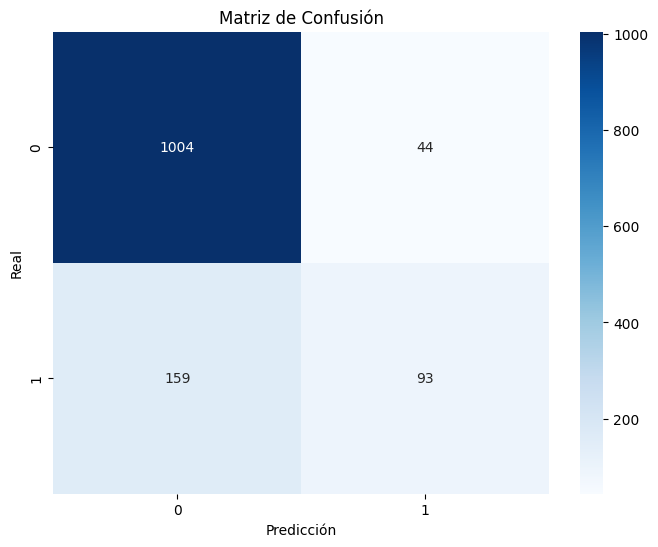

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.86      0.96      0.91      1048
           1       0.68      0.37      0.48       252

    accuracy                           0.84      1300
   macro avg       0.77      0.66      0.69      1300
weighted avg       0.83      0.84      0.82      1300



In [ ]:
#Matriz de Correlacion
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión")
plt.show()

#Reporte de Clasificación
print("Reporte de Clasificación:")
print(classification_report(y_test, y_pred))

#curva ROC
y_probs = XGB_Model.predict_proba(X_test)[:, 1]  # Probabilidades para la clase positiva

fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc_score = roc_auc_score(y_test, y_probs)

fig = go.Figure()
fig.add_trace(go.Scatter(x=fpr, y=tpr, mode='lines', name='ROC', line=dict(color='royalblue')))
fig.add_trace(go.Scatter(x=[0, 1], y=[0, 1], mode='lines', name='no_model', line=dict(dash='dash')))
fig.update_layout(title=f'Curva ROC - AUC: {auc_score:.3f}',
                  xaxis_title='Tasa de Falsos Positivos (FPR)',
                  yaxis_title='Tasa de Verdaderos Positivos (TPR)',
                  width=700, height=500)
fig.show()

LightGBM

In [ ]:
LGBM_Model = LGBMClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=-1,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
LGBM_Model.fit(X_train, y_train)
y_pred = LGBM_Model.predict(X_test)
y_proba = LGBM_Model.predict_proba(X_test)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1025, number of negative: 4172
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000508 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1441
[LightGBM] [Info] Number of data points in the train set: 5197, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.197229 -> initscore=-1.403703
[LightGBM] [Info] Start training from score -1.403703


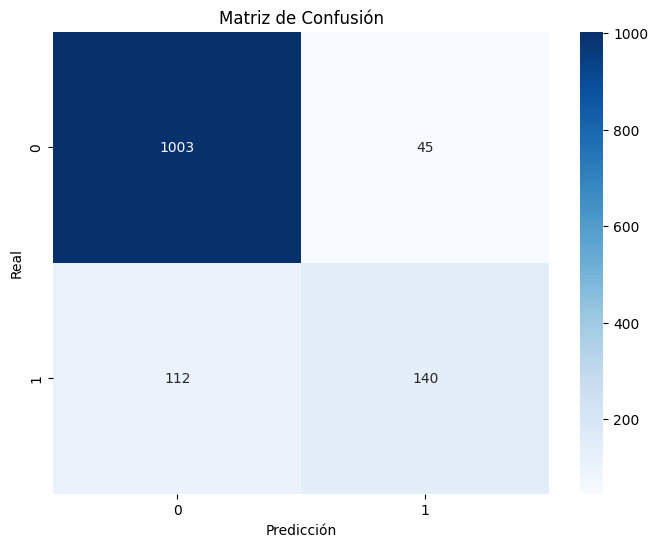

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.90      0.96      0.93      1048
           1       0.76      0.56      0.64       252

    accuracy                           0.88      1300
   macro avg       0.83      0.76      0.78      1300
weighted avg       0.87      0.88      0.87      1300



In [ ]:
#Matriz de Correlacion
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión")
plt.show()

#Reporte de Clasificación
print("Reporte de Clasificación:")
print(classification_report(y_test, y_pred))

#curva ROC
y_probs = LGBM_Model.predict_proba(X_test)[:, 1]  # Probabilidades para la clase positiva

fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc_score = roc_auc_score(y_test, y_probs)

fig = go.Figure()
fig.add_trace(go.Scatter(x=fpr, y=tpr, mode='lines', name='ROC', line=dict(color='royalblue')))
fig.add_trace(go.Scatter(x=[0, 1], y=[0, 1], mode='lines', name='no_model', line=dict(dash='dash')))
fig.update_layout(title=f'Curva ROC - AUC: {auc_score:.3f}',
                  xaxis_title='Tasa de Falsos Positivos (FPR)',
                  yaxis_title='Tasa de Verdaderos Positivos (TPR)',
                  width=700, height=500)
fig.show()

CatBoost

In [ ]:
CAT_Model = CatBoostClassifier(
    iterations=100,
    learning_rate=0.1,
    depth=6,
    verbose=0,
    random_state=42
)

CAT_Model.fit(X_train, y_train)
y_pred = CAT_Model.predict(X_test)
y_proba = CAT_Model.predict_proba(X_test)

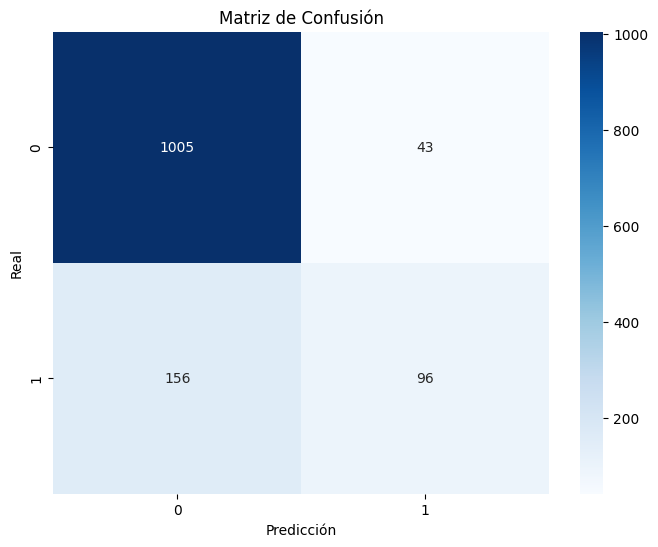

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.87      0.96      0.91      1048
           1       0.69      0.38      0.49       252

    accuracy                           0.85      1300
   macro avg       0.78      0.67      0.70      1300
weighted avg       0.83      0.85      0.83      1300



In [ ]:
#Matriz de Correlacion
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión")
plt.show()

#Reporte de Clasificación
print("Reporte de Clasificación:")
print(classification_report(y_test, y_pred))

#curva ROC
y_probs = CAT_Model.predict_proba(X_test)[:, 1]  # Probabilidades para la clase positiva

fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc_score = roc_auc_score(y_test, y_probs)

fig = go.Figure()
fig.add_trace(go.Scatter(x=fpr, y=tpr, mode='lines', name='ROC', line=dict(color='royalblue')))
fig.add_trace(go.Scatter(x=[0, 1], y=[0, 1], mode='lines', name='no_model', line=dict(dash='dash')))
fig.update_layout(title=f'Curva ROC - AUC: {auc_score:.3f}',
                  xaxis_title='Tasa de Falsos Positivos (FPR)',
                  yaxis_title='Tasa de Verdaderos Positivos (TPR)',
                  width=700, height=500)
fig.show()

Nos decantamos por el LightGBM, al tener un comportamiento superior al resto, ahora estimaremos los mejores parametros para mejorar su predicción

In [ ]:
#Duración de este query aprox 20 minutos
# diccionario de parametros
param_grid = {
    'num_leaves': [10,25, 50],
    'max_depth': [5, 10, 15],
    'learning_rate': [0.03,0.5, 0.1],
    'n_estimators': [100,200,300],
    'subsample': [0.8],
    'colsample_bytree': [0.8]
}

model = LGBMClassifier(random_state=42, n_jobs=-1)

grid = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    verbose=0, #EVita que en la pantalla se desplieguen los calculos
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Mejores parámetros:", grid.best_params_)


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1025, number of negative: 4172
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006675 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1441
[LightGBM] [Info] Number of data points in the train set: 5197, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.197229 -> initscore=-1.403703
[LightGBM] [Info] Start training from score -1.403703
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Mejores parámetros: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 15, 'n_estimators': 300, 'num_leaves': 50, 'subsample': 0.8}


In [ ]:
#Modelo optimo
LGBM_Model = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=15,
    num_leaves=50,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
LGBM_Model.fit(X_train, y_train)
y_pred = LGBM_Model.predict(X_test)
y_proba = LGBM_Model.predict_proba(X_test)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1025, number of negative: 4172
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000457 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1441
[LightGBM] [Info] Number of data points in the train set: 5197, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.197229 -> initscore=-1.403703
[LightGBM] [Info] Start training from score -1.403703
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


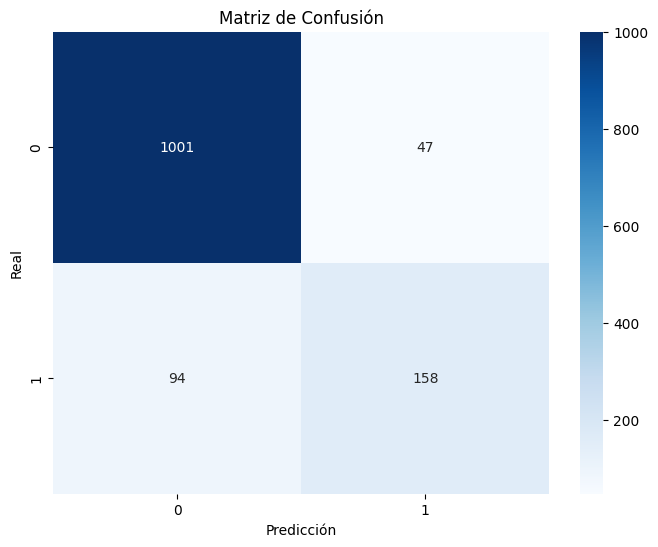

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.91      0.96      0.93      1048
           1       0.77      0.63      0.69       252

    accuracy                           0.89      1300
   macro avg       0.84      0.79      0.81      1300
weighted avg       0.89      0.89      0.89      1300



In [ ]:
#Matriz de Correlacion
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión")
plt.show()

#Reporte de Clasificación
print("Reporte de Clasificación:")
print(classification_report(y_test, y_pred))

#curva ROC
y_probs = LGBM_Model.predict_proba(X_test)[:, 1]  # Probabilidades para la clase positiva

fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc_score = roc_auc_score(y_test, y_probs)

fig = go.Figure()
fig.add_trace(go.Scatter(x=fpr, y=tpr, mode='lines', name='ROC', line=dict(color='royalblue')))
fig.add_trace(go.Scatter(x=[0, 1], y=[0, 1], mode='lines', name='no_model', line=dict(dash='dash')))
fig.update_layout(title=f'Curva ROC - AUC: {auc_score:.3f}',
                  xaxis_title='Tasa de Falsos Positivos (FPR)',
                  yaxis_title='Tasa de Verdaderos Positivos (TPR)',
                  width=700, height=500)
fig.show()

Aplicación en test de seasonal vaccine

In [ ]:
# obtener desde GitHub
url_flu_codificado = "https://raw.githubusercontent.com/jesustristan17/Curso-Machine-Learning/refs/heads/main/datasets/Flu%20Shot%20Learning/flu_filtrado_codificado.csv"
url_flu_test = "https://raw.githubusercontent.com/jesustristan17/Curso-Machine-Learning/refs/heads/main/datasets/Flu%20Shot%20Learning/flu_test_final_codificado.csv"

# Carga los datos
flu_codificado = pd.read_csv(url_flu_codificado)
print(flu_codificado.head())

flu_test = pd.read_csv(url_flu_test)
print(flu_test.head())


   opinion_seas_vacc_effective  opinion_seas_risk  doctor_recc_seasonal  \
0                          2.0                1.0                   0.0   
1                          4.0                2.0                   0.0   
2                          4.0                1.0                   0.0   
3                          5.0                4.0                   1.0   
4                          3.0                1.0                   0.0   

   age_group  opinion_h1n1_risk  opinion_h1n1_vacc_effective  \
0          3                1.0                          3.0   
1          1                4.0                          5.0   
2          0                1.0                          3.0   
3          4                3.0                          3.0   
4          2                3.0                          3.0   

   employment_industry  doctor_recc_h1n1  employment_occupation  \
0                   11               0.0                     11   
1                   13        

In [ ]:
# Cargar dataset limpio
X = flu_codificado.drop(columns='seasonal_vaccine')
y = flu_codificado['seasonal_vaccine']

# Separar datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42
)


AdaBoost

In [ ]:
AB_Model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=100,
    learning_rate=0.5,
    random_state=42
)
AB_Model.fit(X_train, y_train)
y_pred = AB_Model.predict(X_test)
y_proba = AB_Model.predict_proba(X_test)


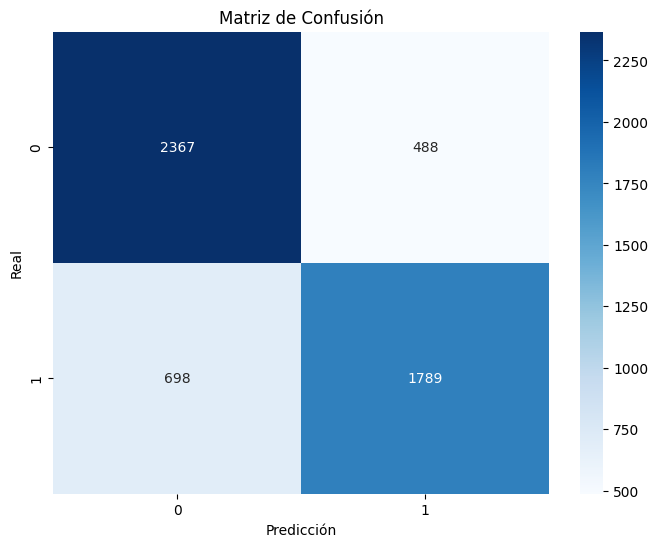

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.77      0.83      0.80      2855
           1       0.79      0.72      0.75      2487

    accuracy                           0.78      5342
   macro avg       0.78      0.77      0.78      5342
weighted avg       0.78      0.78      0.78      5342



In [ ]:
#Matriz de Correlacion
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión")
plt.show()

#Reporte de Clasificación
print("Reporte de Clasificación:")
print(classification_report(y_test, y_pred))

#curva ROC
y_probs = AB_Model.predict_proba(X_test)[:, 1]  # Probabilidades para la clase positiva

fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc_score = roc_auc_score(y_test, y_probs)

fig = go.Figure()
fig.add_trace(go.Scatter(x=fpr, y=tpr, mode='lines', name='ROC', line=dict(color='royalblue')))
fig.add_trace(go.Scatter(x=[0, 1], y=[0, 1], mode='lines', name='no_model', line=dict(dash='dash')))
fig.update_layout(title=f'Curva ROC - AUC: {auc_score:.3f}',
                  xaxis_title='Tasa de Falsos Positivos (FPR)',
                  yaxis_title='Tasa de Verdaderos Positivos (TPR)',
                  width=700, height=500)
fig.show()


GBM

In [ ]:
GBM_Model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    subsample=0.8,
    random_state=42
)
GBM_Model.fit(X_train, y_train)
y_pred = GBM_Model.predict(X_test)
y_proba = GBM_Model.predict_proba(X_test)

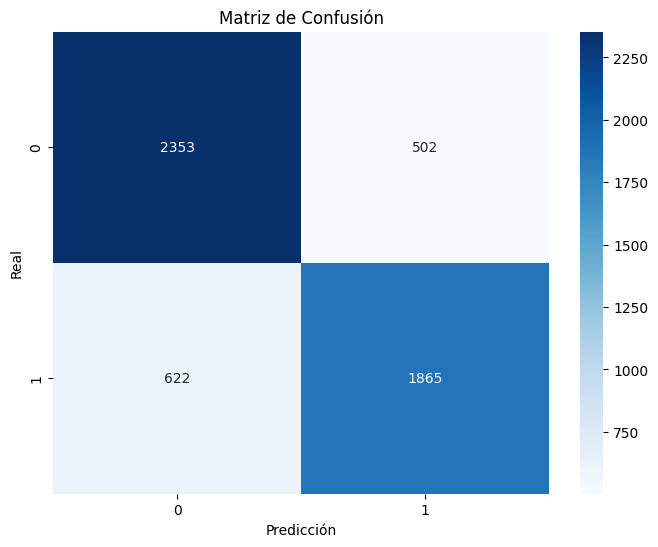

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.79      0.82      0.81      2855
           1       0.79      0.75      0.77      2487

    accuracy                           0.79      5342
   macro avg       0.79      0.79      0.79      5342
weighted avg       0.79      0.79      0.79      5342



In [ ]:
#Matriz de Correlacion
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión")
plt.show()

#Reporte de Clasificación
print("Reporte de Clasificación:")
print(classification_report(y_test, y_pred))

#curva ROC
y_probs = GBM_Model.predict_proba(X_test)[:, 1]  # Probabilidades para la clase positiva

fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc_score = roc_auc_score(y_test, y_probs)

fig = go.Figure()
fig.add_trace(go.Scatter(x=fpr, y=tpr, mode='lines', name='ROC', line=dict(color='royalblue')))
fig.add_trace(go.Scatter(x=[0, 1], y=[0, 1], mode='lines', name='no_model', line=dict(dash='dash')))
fig.update_layout(title=f'Curva ROC - AUC: {auc_score:.3f}',
                  xaxis_title='Tasa de Falsos Positivos (FPR)',
                  yaxis_title='Tasa de Verdaderos Positivos (TPR)',
                  width=700, height=500)
fig.show()


XGB

In [ ]:
XGB_Model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)
XGB_Model.fit(X_train, y_train)
y_pred = XGB_Model.predict(X_test)
y_proba = XGB_Model.predict_proba(X_test)



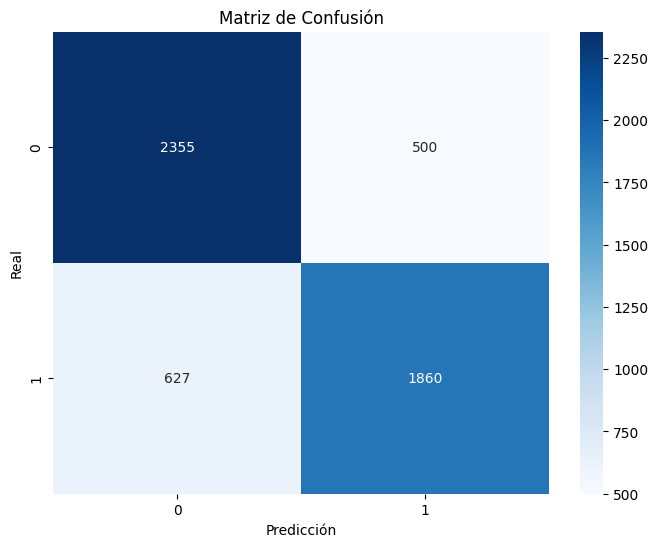

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.79      0.82      0.81      2855
           1       0.79      0.75      0.77      2487

    accuracy                           0.79      5342
   macro avg       0.79      0.79      0.79      5342
weighted avg       0.79      0.79      0.79      5342



In [ ]:
#Matriz de Correlacion
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión")
plt.show()

#Reporte de Clasificación
print("Reporte de Clasificación:")
print(classification_report(y_test, y_pred))

#curva ROC
y_probs = XGB_Model.predict_proba(X_test)[:, 1]  # Probabilidades para la clase positiva

fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc_score = roc_auc_score(y_test, y_probs)

fig = go.Figure()
fig.add_trace(go.Scatter(x=fpr, y=tpr, mode='lines', name='ROC', line=dict(color='royalblue')))
fig.add_trace(go.Scatter(x=[0, 1], y=[0, 1], mode='lines', name='no_model', line=dict(dash='dash')))
fig.update_layout(title=f'Curva ROC - AUC: {auc_score:.3f}',
                  xaxis_title='Tasa de Falsos Positivos (FPR)',
                  yaxis_title='Tasa de Verdaderos Positivos (TPR)',
                  width=700, height=500)
fig.show()

LightGBM

In [ ]:
LGBM_Model = LGBMClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=-1,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
LGBM_Model.fit(X_train, y_train)
y_pred = LGBM_Model.predict(X_test)
y_proba = LGBM_Model.predict_proba(X_test)

[LightGBM] [Info] Number of positive: 9948, number of negative: 11417
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.025193 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 381
[LightGBM] [Info] Number of data points in the train set: 21365, number of used features: 25
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.465621 -> initscore=-0.137732
[LightGBM] [Info] Start training from score -0.137732


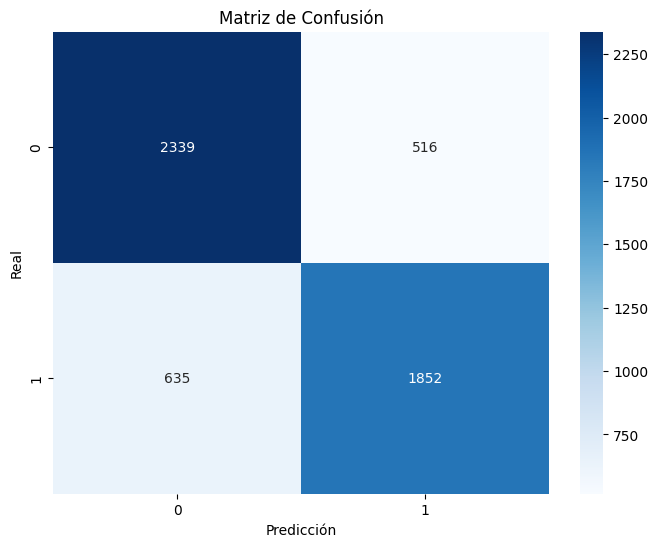

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.79      0.82      0.80      2855
           1       0.78      0.74      0.76      2487

    accuracy                           0.78      5342
   macro avg       0.78      0.78      0.78      5342
weighted avg       0.78      0.78      0.78      5342



In [ ]:
#Matriz de Correlacion
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión")
plt.show()

#Reporte de Clasificación
print("Reporte de Clasificación:")
print(classification_report(y_test, y_pred))

#curva ROC
y_probs = LGBM_Model.predict_proba(X_test)[:, 1]  # Probabilidades para la clase positiva

fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc_score = roc_auc_score(y_test, y_probs)

fig = go.Figure()
fig.add_trace(go.Scatter(x=fpr, y=tpr, mode='lines', name='ROC', line=dict(color='royalblue')))
fig.add_trace(go.Scatter(x=[0, 1], y=[0, 1], mode='lines', name='no_model', line=dict(dash='dash')))
fig.update_layout(title=f'Curva ROC - AUC: {auc_score:.3f}',
                  xaxis_title='Tasa de Falsos Positivos (FPR)',
                  yaxis_title='Tasa de Verdaderos Positivos (TPR)',
                  width=700, height=500)
fig.show()

CatBoost

In [ ]:
CAT_Model = CatBoostClassifier(
    iterations=100,
    learning_rate=0.1,
    depth=6,
    verbose=0,
    random_state=42
)

CAT_Model.fit(X_train, y_train)
y_pred = CAT_Model.predict(X_test)
y_proba = CAT_Model.predict_proba(X_test)

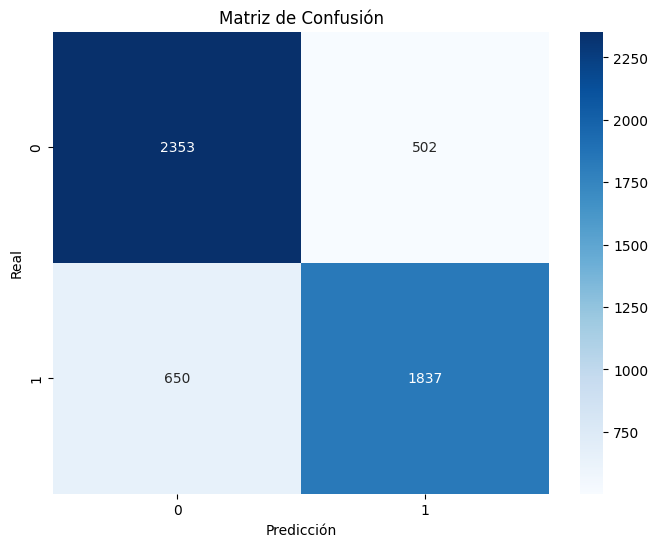

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.78      0.82      0.80      2855
           1       0.79      0.74      0.76      2487

    accuracy                           0.78      5342
   macro avg       0.78      0.78      0.78      5342
weighted avg       0.78      0.78      0.78      5342



In [ ]:
#Matriz de Correlacion
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión")
plt.show()

#Reporte de Clasificación
print("Reporte de Clasificación:")
print(classification_report(y_test, y_pred))

#curva ROC
y_probs = CAT_Model.predict_proba(X_test)[:, 1]  # Probabilidades para la clase positiva

fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc_score = roc_auc_score(y_test, y_probs)

fig = go.Figure()
fig.add_trace(go.Scatter(x=fpr, y=tpr, mode='lines', name='ROC', line=dict(color='royalblue')))
fig.add_trace(go.Scatter(x=[0, 1], y=[0, 1], mode='lines', name='no_model', line=dict(dash='dash')))
fig.update_layout(title=f'Curva ROC - AUC: {auc_score:.3f}',
                  xaxis_title='Tasa de Falsos Positivos (FPR)',
                  yaxis_title='Tasa de Verdaderos Positivos (TPR)',
                  width=700, height=500)
fig.show()

In [ ]:
# Definir los modelos de boosting
boosting_models = [
    AdaBoostClassifier(random_state=42),
    GradientBoostingClassifier(random_state=42),
    CatBoostClassifier(random_state=42, verbose=0),
    LGBMClassifier(random_state=42, verbose=-1),
    XGBClassifier(random_state=42, verbosity=0, use_label_encoder=False)
]

# Nombres de los modelos
boosting_names = [
    'AdaBoost Classifier',
    'Gradient Boosting Classifier',
    'CatBoost Classifier',
    'LightGBM Classifier',
    'XGBoost Classifier'
]

# Inicializar listas para resultados
accuracy = []
std = []

# Validación cruzada
cv = KFold(n_splits=10, shuffle=True, random_state=1)
for model in boosting_models:
    n_scores = cross_val_score(model, X, y, scoring='accuracy', cv=cv, n_jobs=1, error_score='raise')
    accuracy.append(np.mean(n_scores))
    std.append(np.std(n_scores))

# DataFrame con resultados
score_df = pd.DataFrame({
    'Model': boosting_names,
    'Accuracy': accuracy,
    'Std': std
})

# Mostrar resultados
score_df_sorted = score_df.sort_values(by='Accuracy', ascending=False)
print(score_df_sorted)



                          Model  Accuracy       Std
2           CatBoost Classifier  0.784963  0.007277
1  Gradient Boosting Classifier  0.783465  0.009450
3           LightGBM Classifier  0.782828  0.007208
0           AdaBoost Classifier  0.775302  0.007508
4            XGBoost Classifier  0.774254  0.007522


In [ ]:
from catboost import CatBoostClassifier
from sklearn.model_selection import GridSearchCV

# Modelo base
model = CatBoostClassifier(verbose=0, random_state=42)

# diccionarios de marametros
param_grid = {
    'depth': [6, 8],
    'learning_rate': [0.05, 0.1],
    'iterations': [100, 250],
    'l2_leaf_reg': [3,5]
}

grid = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=0
)

grid.fit(X, y)

print("Mejores parámetros:", grid.best_params_)


Mejores parámetros: {'depth': 8, 'iterations': 100, 'l2_leaf_reg': 3, 'learning_rate': 0.05}


In [ ]:
CAT_Model = CatBoostClassifier(
    iterations=100,
    learning_rate=0.05,
    depth=8,
    verbose=0,
    l2_leaf_reg=3,
    random_state=42
)

CAT_Model.fit(X_train, y_train)
y_pred = CAT_Model.predict(X_test)
y_proba = CAT_Model.predict_proba(X_test)

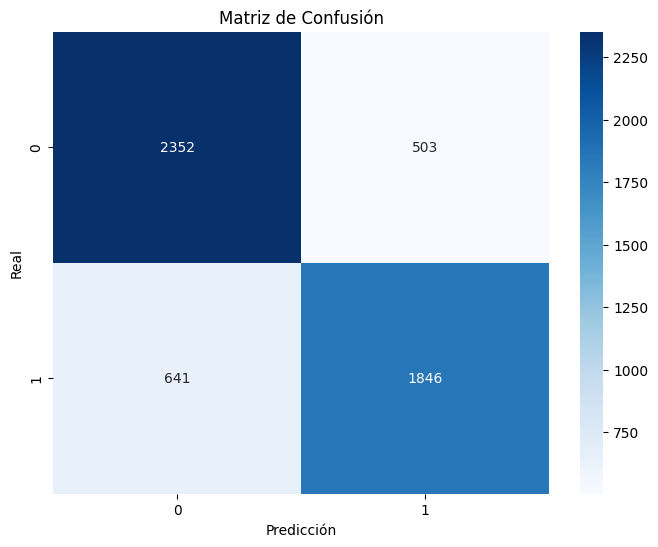

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.79      0.82      0.80      2855
           1       0.79      0.74      0.76      2487

    accuracy                           0.79      5342
   macro avg       0.79      0.78      0.78      5342
weighted avg       0.79      0.79      0.79      5342



In [ ]:
#Matriz de Correlacion
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión")
plt.show()

#Reporte de Clasificación
print("Reporte de Clasificación:")
print(classification_report(y_test, y_pred))

#curva ROC
y_probs = CAT_Model.predict_proba(X_test)[:, 1]  # Probabilidades para la clase positiva

fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc_score = roc_auc_score(y_test, y_probs)

fig = go.Figure()
fig.add_trace(go.Scatter(x=fpr, y=tpr, mode='lines', name='ROC', line=dict(color='royalblue')))
fig.add_trace(go.Scatter(x=[0, 1], y=[0, 1], mode='lines', name='no_model', line=dict(dash='dash')))
fig.update_layout(title=f'Curva ROC - AUC: {auc_score:.3f}',
                  xaxis_title='Tasa de Falsos Positivos (FPR)',
                  yaxis_title='Tasa de Verdaderos Positivos (TPR)',
                  width=700, height=500)
fig.show()

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from datetime import datetime
import pandas as pd

CAT_Model = CatBoostClassifier(
    iterations=100,
    learning_rate=0.05,
    depth=8,
    verbose=0,
    l2_leaf_reg=3,
    random_state=42
)

CAT_Model.fit(X_train, y_train)

flu_test = flu_test.drop(columns=['predicted_score'], errors='ignore')


assert set(X_train.columns).issubset(flu_test.columns), "flu_test debe contener las mismas variables que X_train"

# Obtener las probabilidades de la clase positiva
probs = CAT_Model.predict_proba(flu_test[X_train.columns])[:, 1]

# Agregar la columna de score redondeado
flu_test = flu_test.copy()
flu_test['predicted_score'] = probs.round(3)

# Seleccionar columnas relevantes
pred_flu = flu_test[['respondent_id', 'predicted_score']].sort_values(by='predicted_score', ascending=False)

# Generar nombre de archivo con timestamp
timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M")
file_name = f"Cat_output_{timestamp}.csv"

# Exportar a CSV
pred_flu.to_csv(file_name, index=False)

# Mostrar resultados
display(pred_flu)

,respondent_id,predicted_score
4741,31448,0.988
1614,28321,0.985
11920,38627,0.981
2743,29450,0.981
15486,42193,0.980
...,...,...
2527,29234,0.016
24927,51634,0.015
12029,38736,0.015
17904,44611,0.014


Tarea: replicar los resultados con el resto de modelos de boosting y lo mismo para la vacuna H1N1. Subir a la pagina para ver desempeños